In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/processed'

df_train = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_train.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'ubuntu_server_dataset_test.csv'))

# Limpeza inicial comum a ambos os DataFrames
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

print("Dados carregados e limpos com sucesso.")
print(f"Formato do conjunto de treino: {df_train.shape}")
print(f"Formato do conjunto de teste: {df_test.shape}")

Dados carregados e limpos com sucesso.
Formato do conjunto de treino: (12252, 44)
Formato do conjunto de teste: (5254, 44)


In [3]:
# Filtrar o conjunto de treino para conter APENAS o tráfego normal
df_train_normal = df_train[df_train['label'] == 0]
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)

print(f"Número de amostras de treino (apenas normais): {len(X_train_normal)}")

# Definir o pré-processador
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Ajustar (fit) o pré-processador nos dados de treino normais
print("\nAjustando o pré-processador...")
preprocessor.fit(X_train_normal)

# Transformar os dados de treino para usar no treinamento do modelo
X_train_normal_processed = preprocessor.transform(X_train_normal)

print("Pré-processador treinado com sucesso e dados de treino transformados.")

Número de amostras de treino (apenas normais): 5382

Ajustando o pré-processador...
Pré-processador treinado com sucesso e dados de treino transformados.


In [4]:
# Instanciar o modelo Isolation Forest
iso_forest = IsolationForest(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

print("Iniciando o treinamento do modelo Isolation Forest...")
# O fit é feito SEM RÓTulos (y), apenas com os dados normais processados
iso_forest.fit(X_train_normal_processed)

print("Treinamento do Isolation Forest concluído. O modelo está pronto.")

Iniciando o treinamento do modelo Isolation Forest...
Treinamento do Isolation Forest concluído. O modelo está pronto.


In [5]:
# Separar o tráfego normal do tráfego de ataque no conjunto de teste
df_test_normal = df_test[df_test['label'] == 0]
df_test_attacks = df_test[df_test['label'] == 1]

# Definir a taxa de contaminação alvo
target_contamination = 0.49

# Calcular o número de amostras de ataque a serem mantidas
n_normal_samples = len(df_test_normal)
n_attacks_to_keep = int(((target_contamination * n_normal_samples) / (1 - target_contamination))/3)

print(f"Mantendo {len(df_test_normal)} amostras normais e {n_attacks_to_keep} amostras de ataque.")

# Realizar a subamostragem estratificada
df_attacks_subsampled, _ = train_test_split(
    df_test_attacks,
    train_size=n_attacks_to_keep,
    random_state=42,
    stratify=df_test_attacks['attack_cat']
)

# Criar o novo conjunto de teste subamostrado
df_test_subsampled = pd.concat([df_test_normal, df_attacks_subsampled])
print(f"Novo conjunto de teste criado com {len(df_test_subsampled)} amostras.")
print(f"Nova taxa de contaminação: {len(df_attacks_subsampled) / len(df_test_subsampled):.4f}")

Mantendo 2307 amostras normais e 738 amostras de ataque.
Novo conjunto de teste criado com 3045 amostras.
Nova taxa de contaminação: 0.2424


Transformando os dados do teste subamostrado...
Realizando previsões...

--- Relatório de Classificação Binária (Isolation Forest no Teste Subamostrado) ---
              precision    recall  f1-score   support

  Normal (0)       0.98      0.71      0.82      2307
  Ataque (1)       0.51      0.96      0.67       738

    accuracy                           0.77      3045
   macro avg       0.75      0.83      0.75      3045
weighted avg       0.87      0.77      0.79      3045



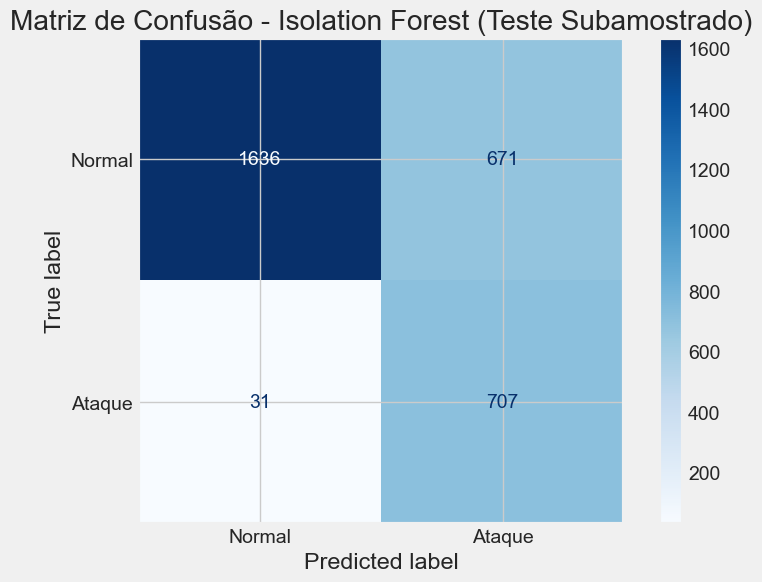

In [6]:
# Preparar X e y do novo conjunto de teste
X_test_subsampled = df_test_subsampled.drop(['attack_cat', 'label'], axis=1)
y_test_subsampled = df_test_subsampled['label']

# Transformar os dados de teste com o pré-processador já treinado
print("Transformando os dados do teste subamostrado...")
X_test_subsampled_processed = preprocessor.transform(X_test_subsampled)

# Ajustar o parâmetro 'contamination' do modelo já treinado
iso_forest.contamination = target_contamination

# Realizar previsões no novo conjunto de teste
print("Realizando previsões...")
y_pred_subsampled = iso_forest.predict(X_test_subsampled_processed)

# Mapear os resultados (1 para normal, -1 para anomalia -> 0 para normal, 1 para ataque)
y_pred_mapped_subsampled = np.where(y_pred_subsampled == 1, 0, 1)

# Avaliar os resultados
print("\n--- Relatório de Classificação Binária (Isolation Forest no Teste Subamostrado) ---")
print(classification_report(y_test_subsampled, y_pred_mapped_subsampled, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test_subsampled, y_pred_mapped_subsampled)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Isolation Forest (Teste Subamostrado)')
plt.savefig('confusion_matrix_multi_if_subsampled.png')
plt.show()

In [7]:
try:
    # Salvar o Pré-processador
    joblib.dump(preprocessor, 'preprocessor_IF-Subsampled.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")
    
    # Salvar o Modelo Isolation Forest treinado
    joblib.dump(iso_forest, 'model_IF-Subsampled.joblib')
    print("Modelo 'iso_forest' salvo com sucesso.")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
Modelo 'iso_forest' salvo com sucesso.
